<a href="https://colab.research.google.com/github/noecastilloz/analisis-de-la-calidad-del-aire-en-mexico/blob/main/Calidad_del_aire_en_M%C3%A9xico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio de Datos (EDA): Calidad del Aire en México

## 1. Introducción y Objetivos
Este notebook realiza un Análisis Exploratorio de Datos (EDA) sobre las mediciones históricas de calidad del aire y variables meteorológicas registradas por diversas estaciones de monitoreo en México.

### Objetivos Principales:
- **Limpieza y Criterio Físico:** Identificar y tratar adecuadamente valores corruptos o imposibles (> 10,000 µg/m³) originados por desbordamientos o fallas de sensores.
- **Tratamiento de Series Temporales:** Imputar datos faltantes respetando la continuidad temporal por estación mediante interpolación lineal y medianas locales.
- **Análisis Estadístico de Contaminantes:** Evaluar la distribución y el impacto de eventos atípicos en $PM_{2.5}$.
- **Patrones Estacionales y Espaciales:** Analizar las tendencias de contaminación a lo largo del tiempo (mes/año) y determinar las estaciones con mayores niveles de emisión.
- **Dinámica Atmosférica:** Estudiar las relaciones físicas entre material particulado ($PM_{2.5}, PM_{10}$) y gases fotoquímicos ($O_3, NO_2$) mediante la agregación mensual.

---
## Carga de Librerías y Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/stations_daily.csv')

In [ ]:
df.head(5)

,datetime,station_id,PM2.5,PM10,NOx,O3,CO,HR,NO,NO2,...,HCT,HRI,IUV,PB,PP,PST,RS,TMPI,UVA,XIL
0,2015-04-02,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.361000,NaN,NaN
1,2015-05-21,32,0.454967,0.347400,0.059194,0.029176,NaN,44.879091,0.029525,0.053121,...,NaN,NaN,NaN,570.775455,0.296364,NaN,7.871636,16.792818,NaN,NaN
2,2015-05-22,32,0.077821,0.389323,0.019158,0.051903,NaN,42.506000,0.009589,0.014215,...,NaN,NaN,NaN,558.360000,0.002750,NaN,384.788079,17.018949,NaN,NaN
3,2015-05-23,32,0.018036,0.387729,0.019711,0.021092,0.144603,54.734437,0.009863,0.013436,...,NaN,NaN,NaN,573.282187,0.038750,NaN,252.605975,18.575000,NaN,NaN
4,2015-05-24,32,0.024935,0.398042,0.024757,0.009568,0.494143,58.374574,0.012397,0.010337,...,NaN,NaN,NaN,572.169574,0.003404,NaN,259.231664,16.781064,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231592 entries, 0 to 231591
Data columns (total 27 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   datetime    231592 non-null  object 
 1   station_id  231592 non-null  int64  
 2   PM2.5       161698 non-null  float64
 3   PM10        180481 non-null  float64
 4   NOx         112881 non-null  float64
 5   O3          192957 non-null  float64
 6   CO          175493 non-null  float64
 7   HR          123285 non-null  float64
 8   NO          118154 non-null  float64
 9   NO2         169286 non-null  float64
 10  TMP         127015 non-null  float64
 11  BEN         775 non-null     float64
 12  CH4         270 non-null     float64
 13  CN          595 non-null     float64
 14  CO2         56 non-null      float64
 15  H2S         280 non-null     float64
 16  HCNM        279 non-null     float64
 17  HCT         0 non-null       float64
 18  HRI         10205 non-null   float64
 19  IU

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231592 entries, 0 to 231591
Data columns (total 27 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   datetime    231592 non-null  datetime64[ns]
 1   station_id  231592 non-null  int64         
 2   PM2.5       161698 non-null  float64       
 3   PM10        180481 non-null  float64       
 4   NOx         112881 non-null  float64       
 5   O3          192957 non-null  float64       
 6   CO          175493 non-null  float64       
 7   HR          123285 non-null  float64       
 8   NO          118154 non-null  float64       
 9   NO2         169286 non-null  float64       
 10  TMP         127015 non-null  float64       
 11  BEN         775 non-null     float64       
 12  CH4         270 non-null     float64       
 13  CN          595 non-null     float64       
 14  CO2         56 non-null      float64       
 15  H2S         280 non-null     float64       
 16  HC

In [ ]:
df.isnull().sum()

,0
datetime,0
station_id,0
PM2.5,69894
PM10,51111
NOx,118711
O3,38635
CO,56099
HR,108307
NO,113438
NO2,62306


In [ ]:
columnas_eliminar =['BEN', 'CH4', 'CN', 'CO2', 'H2S', 'HCNM', 'HCT', 'HRI', 'IUV', 'PST', 'UVA', 'XIL']
df = df.drop(columns=columnas_eliminar)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231592 entries, 0 to 231591
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   datetime    231592 non-null  datetime64[ns]
 1   station_id  231592 non-null  int64         
 2   PM2.5       161698 non-null  float64       
 3   PM10        180481 non-null  float64       
 4   NOx         112881 non-null  float64       
 5   O3          192957 non-null  float64       
 6   CO          175493 non-null  float64       
 7   HR          123285 non-null  float64       
 8   NO          118154 non-null  float64       
 9   NO2         169286 non-null  float64       
 10  TMP         127015 non-null  float64       
 11  PB          91738 non-null   float64       
 12  PP          75346 non-null   float64       
 13  RS          75507 non-null   float64       
 14  TMPI        34385 non-null   float64       
dtypes: datetime64[ns](1), float64(13), int64(1)
memory 

## 2. Limpieza de datos e imputación temporal

Para evitar sesgar la distribución de contaminantes, se implementó un pipeline en tres etapas:

1. **Filtrado físico:** Reemplazo de lecturas astronómicas/corruptas (> 10,000 µg/m³) por `NaN`.

2. **Interpolación temporal por estación:** Dado que la calidad del aire es una serie de tiempo, se interpolan huecos cortos dentro de la misma estación y se usa la mediana local para vacíos mayores.

3. **Manejo de ceros:** Tratamiento de lecturas exactas en 0.0 como sensores inactivos.

In [ ]:
# Definir columnas a limpiar
columnas_numericas = ['PM2.5', 'PM10', 'NOx', 'O3', 'CO', 'HR', 'NO', 'NO2', 'TMP', 'PB', 'PP', 'RS', 'TMPI']

# Reemplazar valores físicamente imposibles (> 10,000) por NaN antes de cualquier cálculo
for col in columnas_numericas:
    df.loc[df[col] > 10000, col] = np.nan

In [ ]:
# 1. Asegurar orden cronológico por estación
df = df.sort_values(['station_id', 'datetime']).reset_index(drop=True)

# 2. Interpolación lineal temporal por cada estación (ideal para series de tiempo de calidad del aire)
for col in columnas_numericas:
    df[col] = df.groupby('station_id')[col].transform(lambda x: x.interpolate(method='linear', limit=3))

# 3. Para periodos faltantes más largos, imputar con la mediana de la MISMA estación
for col in columnas_numericas:
    df[col] = df.groupby('station_id')[col].transform(lambda x: x.fillna(x.median()))

# 4. Si alguna estación no tenía ningún registro en esa variable, rellenar sobrantes con la mediana global
df[columnas_numericas] = df[columnas_numericas].fillna(df[columnas_numericas].median())

In [ ]:
df.isnull().sum()

,0
datetime,0
station_id,0
PM2.5,0
PM10,0
NOx,0
O3,0
CO,0
HR,0
NO,0
NO2,0


In [ ]:
# Reemplazar valores exactos en 0.0 por NaN (para tratar lecturas caídas del sensor)
df.loc[df['PM2.5'] == 0, 'PM2.5'] = np.nan

# Re-imputar esos ceros usando la mediana de su respectiva estación
df['PM2.5'] = df.groupby('station_id')['PM2.5'].transform(lambda x: x.fillna(x.median()))

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,datetime,station_id,PM2.5,PM10,NOx,O3,CO,HR,NO,NO2,TMP,PB,PP,RS,TMPI
count,231592,231592.000000,231592.000000,231592.000000,231592.000000,231592.000000,231592.000000,231592.000000,231592.000000,231592.000000,231592.000000,231592.000000,231592.000000,231592.000000,231592.000000
mean,2016-08-28 18:00:38.799267840,169.260942,31.609381,59.859734,0.152928,0.118738,1.714000,57.549137,0.071369,0.097269,28.069217,620.138078,5.850325,210.834342,20.858341
min,2000-01-01 00:00:00,32.000000,0.000313,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.028861
25%,2014-04-02 00:00:00,93.000000,15.083333,33.432759,0.015183,0.019292,0.559091,49.847392,0.006774,0.010208,17.081250,596.397344,0.000000,172.958333,20.871042
50%,2017-05-18 00:00:00,141.000000,19.594688,45.958333,0.024122,0.025082,0.796667,57.173913,0.010164,0.014909,19.681652,621.715217,0.000000,181.250000,20.871042
75%,2019-08-14 00:00:00,256.000000,25.625000,62.025730,0.036333,0.031667,1.100000,64.208555,0.016974,0.022708,23.213316,645.967708,0.000000,201.464702,20.871042
max,2021-12-31 00:00:00,426.000000,2190.611064,3598.990423,233.880000,143.454565,8788.028452,8925.452105,207.873333,256.713816,2809.509167,1482.853556,9408.000001,9923.382792,8268.433333
std,NaN,92.487547,93.918764,96.860664,2.310604,1.913087,35.493381,37.644279,1.398291,1.591893,61.921013,100.013567,161.472460,203.188304,19.171999


In [ ]:
df['PM2.5'].sort_values(ascending=False).head(10)

,PM2.5
46734,2190.611064
2807,1650.761888
46716,1537.877260
53501,1537.085718
212908,1523.887000
212909,1415.882083
2821,1188.923771
2217,1040.070833
2526,1028.950000
2218,1020.993333


In [ ]:
df.loc[df['PM2.5'].nlargest(10).index,
       ['datetime', 'station_id', 'PM2.5']]

,datetime,station_id,PM2.5
46734,2021-05-16,82,2190.611064
2807,2019-06-21,33,1650.761888
46716,2021-04-28,82,1537.877260
53501,2021-05-05,87,1537.085718
212908,2018-04-12,304,1523.887000
212909,2018-04-13,304,1415.882083
2821,2019-07-05,33,1188.923771
2217,2017-11-04,33,1040.070833
2526,2018-09-11,33,1028.950000
2218,2017-11-05,33,1020.993333


In [ ]:
df['PM2.5'].sort_values().head(10)

,PM2.5
56182,0.000313
14103,0.000500
14102,0.000526
14104,0.000555
14105,0.000566
56183,0.000566
14106,0.000579
56184,0.000623
998,0.000833
990,0.001176


In [ ]:
df.loc[df['PM2.5'] == 0,
       ['datetime', 'station_id', 'PM2.5']].head(20)

,datetime,station_id,PM2.5


In [ ]:
cantidad_ceros = (df['PM2.5'] == 0).sum()

porcentaje_ceros = cantidad_ceros / len(df) * 100

print("Cantidad de ceros:", cantidad_ceros)
print("Porcentaje de ceros:", porcentaje_ceros)

Cantidad de ceros: 0
Porcentaje de ceros: 0.0


In [ ]:
Q1 = df['PM2.5'].quantile(0.25)
Q3 = df['PM2.5'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 15.083333333333334
Q3: 25.625
IQR: 10.541666666666666
Límite inferior: -0.7291666666666661
Límite superior: 41.4375


In [ ]:
outliers_pm25 = df[df['PM2.5'] > limite_superior]

print("Cantidad de outliers:", len(outliers_pm25))
print("Porcentaje:", len(outliers_pm25) / len(df) * 100)

Cantidad de outliers: 13912
Porcentaje: 6.007115962554837


In [ ]:
outliers_pm25[['datetime', 'station_id', 'PM2.5']].sort_values(
    'PM2.5', ascending=False
).head(20)

,datetime,station_id,PM2.5
46734,2021-05-16,82,2190.611064
2807,2019-06-21,33,1650.761888
46716,2021-04-28,82,1537.877260
53501,2021-05-05,87,1537.085718
212908,2018-04-12,304,1523.887000
212909,2018-04-13,304,1415.882083
2821,2019-07-05,33,1188.923771
2217,2017-11-04,33,1040.070833
2526,2018-09-11,33,1028.950000
2218,2017-11-05,33,1020.993333


In [ ]:
df['PM2.5'].describe(percentiles=[0.90, 0.95, 0.99, 0.995])

,PM2.5
count,231592.000000
mean,31.609381
std,93.918764
min,0.000313
50%,19.594688
90%,35.333333
95%,44.208333
99%,520.717083
99.5%,971.000000
max,2190.611064


### Tratamiento de outliers en PM2.5
Aunque el 95% de los datos de PM2.5 se encuentran por debajo de 44.2 µg/m³, persisten valores extremos entre 500 y 2,190 µg/m³ en estaciones específicas (como la 82, 33 y 304).

Dado que no superan el umbral físico de imposibilidad (> 10,000) y representan eventos atípicos reales o fallas puntuales de sensores, no se eliminan del dataset general, pero se acotan en la visualización para no distorsionar la interpretación gráfica.

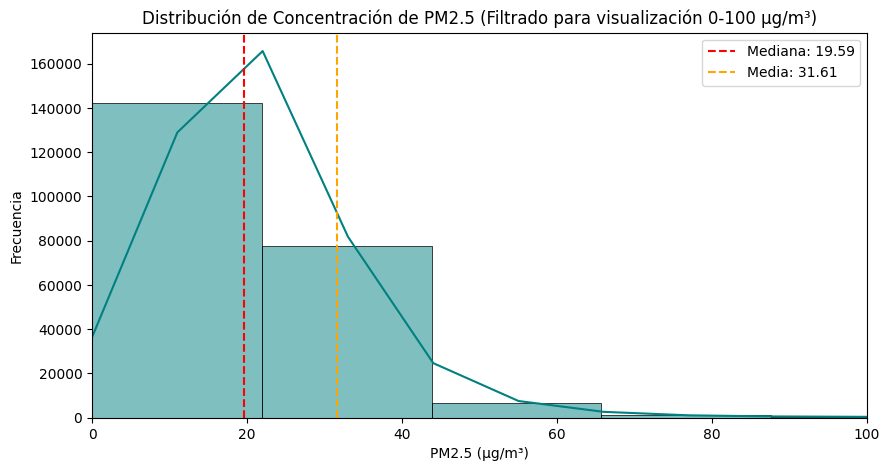

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['PM2.5'], bins=100, kde=True, color='teal')
plt.xlim(0, 100)
plt.title('Distribución de Concentración de PM2.5 (Filtrado para visualización 0-100 µg/m³)')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Frecuencia')
plt.axvline(df['PM2.5'].median(), color='red', linestyle='--', label=f'Mediana: {df["PM2.5"].median():.2f}')
plt.axvline(df['PM2.5'].mean(), color='orange', linestyle='--', label=f'Media: {df["PM2.5"].mean():.2f}')
plt.legend()
plt.show()

## 3. Análisis Exploratorio Temporal
Se extraen componentes temporales (año, mes, día de la semana) para evaluar patrones estacionales de contaminación por `PM2.5` a lo largo de la serie histórica.

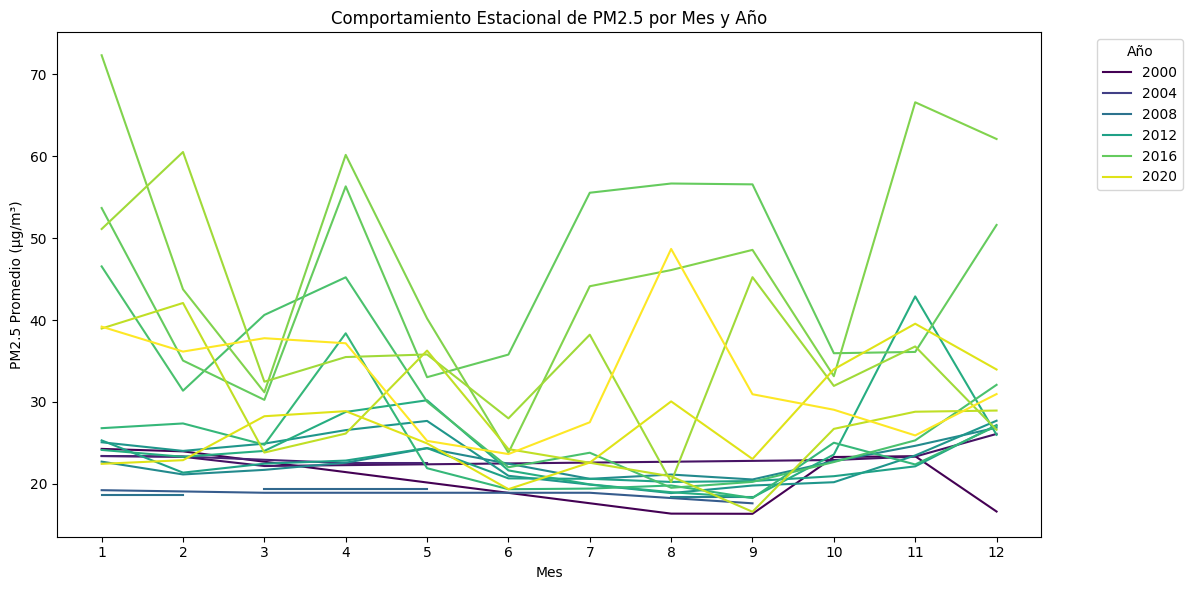

In [ ]:
# Crear columnas de tiempo
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['dayofweek'] = df['datetime'].dt.dayofweek

# Gráfica de tendencia promedio mensual por año
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='month', y='PM2.5', hue='year', palette='viridis', errorbar=None)
plt.title('Comportamiento Estacional de PM2.5 por Mes y Año')
plt.xlabel('Mes')
plt.ylabel('PM2.5 Promedio (µg/m³)')
plt.xticks(range(1, 13))
plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

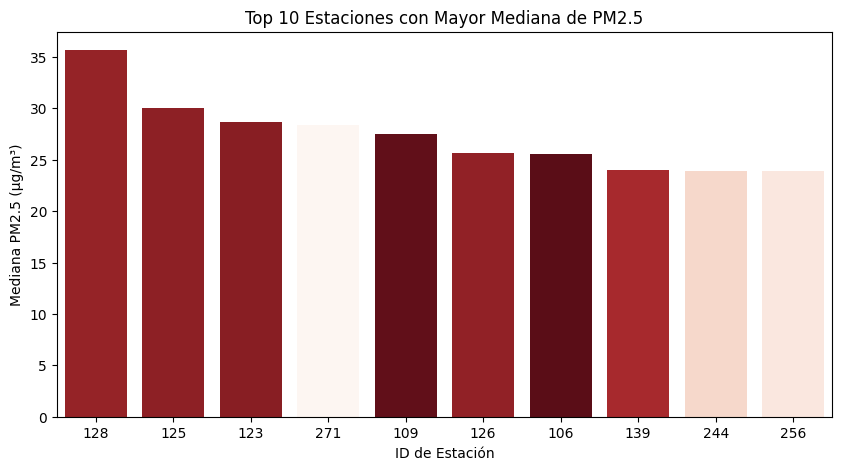

In [ ]:
# Calcular mediana por estación y obtener las 10 más altas
top_estaciones = df.groupby('station_id')['PM2.5'].median().nlargest(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_estaciones,
    x='station_id',
    y='PM2.5',
    hue='station_id',
    palette='Reds_r',
    order=top_estaciones['station_id'],
    legend=False
)
plt.title('Top 10 Estaciones con Mayor Mediana de PM2.5')
plt.xlabel('ID de Estación')
plt.ylabel('Mediana PM2.5 (µg/m³)')
plt.show()

## 4. Matriz de Correlación Atmosférica
Las mediciones diarias individuales sufren de desalineación operativa (sensores inactivos en días específicos). Para capturar las relaciones físicas reales entre contaminantes y clima, se agregan las variables a promedio mensual por estación antes de calcular la matriz de correlación de Pearson.

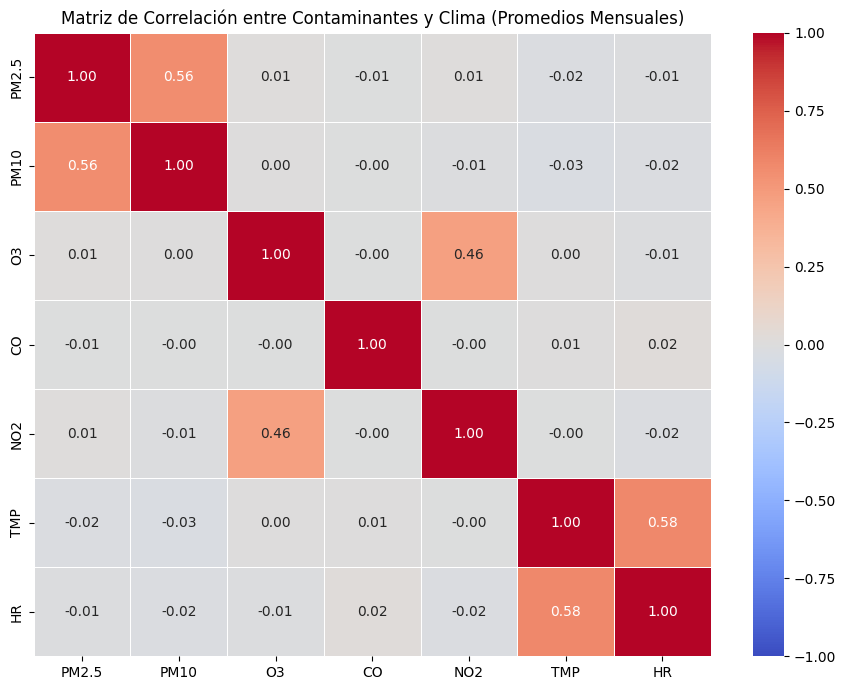

In [ ]:
# 1. Cargar datos originales y filtrar errores de sensor (> 10,000)
df_raw = pd.read_csv('/content/stations_daily.csv')
variables_interes = ['PM2.5', 'PM10', 'O3', 'CO', 'NO2', 'TMP', 'HR']

for col in variables_interes:
    df_raw.loc[df_raw[col] > 10000, col] = np.nan

# 2. Agrupar por estación y mes (promedio) para alinear temporalmente las mediciones de los sensores
df_raw['year_month'] = pd.to_datetime(df_raw['datetime']).dt.to_period('M')
df_monthly = df_raw.groupby(['station_id', 'year_month'])[variables_interes].mean()

# 3. Calcular la matriz de correlación sobre los promedios mensuales
matriz_corr = df_monthly.corr(method='pearson')

# 4. Graficar el Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación entre Contaminantes y Clima (Promedios Mensuales)')
plt.tight_layout()
plt.show()

### Conclusiones del Análisis de Correlación
- **Material Particulado (PM2.5 y PM10):** Presentan una correlación positiva de 0.56, indicando fuentes de emisión e influencia meteorológica compartidas.
- **Ozono y Dióxido de Nitrógeno (O3 y NO2):** Muestran una correlación positiva de 0.46, correspondiente a su dinámica como precursores en reacciones fotoquímicas atmosféricas.
- **Alineación Temporal:** Al agregar los datos a nivel mensual por estación, se eliminó el ruido de desalineación diaria entre sensores, permitiendo capturar las relaciones físicas reales de la calidad del aire.